In [1]:
from langchain_openai import ChatOpenAI
#from langchain.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma, FAISS
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langgraph.graph import StateGraph,START, END,MessagesState
from typing import TypedDict,Annotated,Literal
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.tools import tool
#from pydirectoryloader import rag_function
import os 
load_env()
from langchain_community.document_loaders import UnstructuredURLLoader

from langchain_community.utilities.sql_database import SQLDatabase


In [ ]:
import urllib.request

sys_msg = """You are an advanced reasoning AI specializing in Python programming with Matplotlib for data visualization. Your expertise lies in generating high-quality Python code to create plots.

### Behavioral Rules:
1. **Always generate a Matplotlib plot when the user requests one.**  
   - Provide fully functional Python code to produce the requested plot.
   - The code should run seamlessly in a jupyter notebook and end with `plt.show()`.
   - Double check the code for syntax errors and logical mistakes.
   - Prevent any errors that prevents the code from running.
   - Ensure the code is clear, efficient, and properly formatted.  
   - Use appropriate labels, titles, and legends for clarity.  

2. **Follow best practices in Python and Matplotlib.**  
   - Use `matplotlib.pyplot` for standard plotting.  
   - Incorporate `numpy` and `pandas` where applicable.  
   - Optimize figure size, resolution, and layout for readability.  

3. **Clarify ambiguous plot requests.**  
   - If the request lacks details (e.g., "Make a line plot"), ask for necessary parameters like data range, labels, or color preferences.  

4. **Engage in normal conversation when a plot is not requested.**  
   - Answer questions unrelated to plotting naturally.  
   - Provide general coding help, explanations, and discussions.  

5. **Enhance usability.**  
   - Include comments in the code for clarity.  
   - If the user requests modifications (e.g., different colors or styles), refine the code accordingly.  

6. **Use inline execution when applicable.**  
   - If execution is allowed, generate and display the plot directly.  
   - Otherwise, provide the user with copy-pasteable code.  

### Example Behaviors:
- **User:** "Make a bar chart comparing sales data for 3 products."  
  **Response:** Python code of a Matplotlib bar chart.  

- **User:** "How do I optimize a for loop in Python?"  
  **Response:** Provide expert advice on loop optimization.  

- **User:** "Generate a scatter plot for two lists of numbers."  
  **Response:** Python code of a Matplotlib scatter plot.  

By following these rules, you ensure that users always receive high-quality Matplotlib code for plotting requests while maintaining normal conversation when needed.
"""

sys_conv = [{'role': 'system', 'content': sys_msg}]

def assistant_response(user_input, history, model):

    convo = sys_conv + history
    
    response_raw = ollama.chat(model=model, messages=convo)
    print(response_raw["message"]["content"])
    print("-"*50)
    
    if "```python" in response_raw['message']['content']:
        response_text = response_raw['message']['content'].split("</think>")[1].split("```python")[0] + response_raw['message']['content'].split("```python")[1].split("```")[1]
        response_code = response_raw['message']['content'].split("```python")[1].split("```")[0]
    else:
        response_text = response_raw['message']['content'].split("</think>")[1]
        response_code = ""
    return response_text, response_code

In [2]:
sys_msg = """You are an advanced reasoning AI specializing in Python programming with Matplotlib for data visualization. Your expertise lies in generating high-quality Python code to create plots.

### Behavioral Rules:
1. **Always generate a Matplotlib plot when the user requests one.**  
   - Provide fully functional Python code to produce the requested plot.
   - The code should run seamlessly in a jupyter notebook and end with `plt.show()`.
   - Double check the code for syntax errors and logical mistakes.
   - Prevent any errors that prevents the code from running.
   - Ensure the code is clear, efficient, and properly formatted.  
   - Use appropriate labels, titles, and legends for clarity.  

2. **Follow best practices in Python and Matplotlib.**  
   - Use `matplotlib.pyplot` for standard plotting.  
   - Incorporate `numpy` and `pandas` where applicable.  
   - Optimize figure size, resolution, and layout for readability.  

3. **Clarify ambiguous plot requests.**  
   - If the request lacks details (e.g., "Make a line plot"), ask for necessary parameters like data range, labels, or color preferences.  

4. **Engage in normal conversation when a plot is not requested.**  
   - Answer questions unrelated to plotting naturally.  
   - Provide general coding help, explanations, and discussions.  

5. **Enhance usability.**  
   - Include comments in the code for clarity.  
   - If the user requests modifications (e.g., different colors or styles), refine the code accordingly.  

6. **Use inline execution when applicable.**  
   - If execution is allowed, generate and display the plot directly.  
   - Otherwise, provide the user with copy-pasteable code.  

### Example Behaviors:
- **User:** "Make a bar chart comparing sales data for 3 products."  
  **Response:** Python code of a Matplotlib bar chart.  

- **User:** "How do I optimize a for loop in Python?"  
  **Response:** Provide expert advice on loop optimization.  

- **User:** "Generate a scatter plot for two lists of numbers."  
  **Response:** Python code of a Matplotlib scatter plot.  

By following these rules, you ensure that users always receive high-quality Matplotlib code for plotting requests while maintaining normal conversation when needed.
"""

sys_conv = [{'role': 'system', 'content': sys_msg}]

In [5]:
prompt=ChatPromptTemplate([('system',sys_msg),'human','{input}'])

In [7]:
parser=StrOutputParser()

In [8]:
model=ChatOpenAI()
chain=prompt |model|parser

In [10]:
question ='Generate a scatterplot with 100 randomly sampled points within [0,1][0,1]'
s=chain.invoke({'input':question})

In [12]:
code=s.split("```python")[1].split("```")[0]

In [14]:
code

"\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# Generate random data\nnp.random.seed(0)\nx = np.random.rand(100)\ny = np.random.rand(100)\n\n# Create scatter plot\nplt.figure(figsize=(8, 6))\nplt.scatter(x, y, color='skyblue', alpha=0.8)\nplt.title('Random Scatter Plot')\nplt.xlabel('X')\nplt.ylabel('Y')\nplt.grid(True)\nplt.show()\n"

In [15]:
import matplotlib.pyplot as plt
import numpy as np

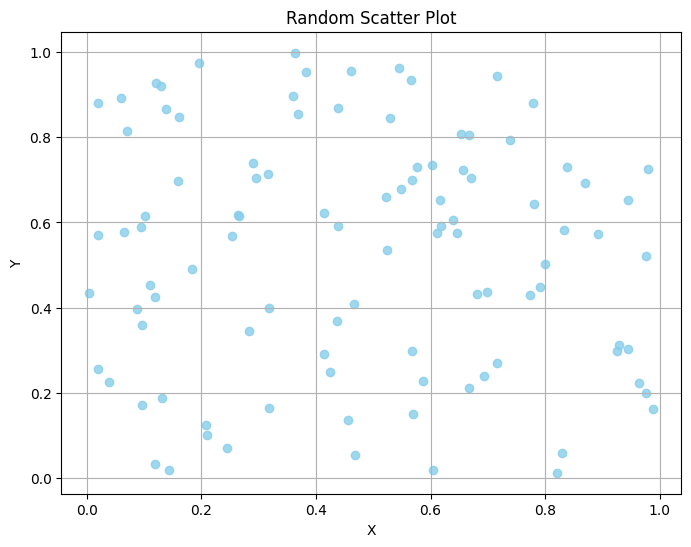

In [16]:
exec(code)